R2 Score: 0.6885
MSE: 0.4737


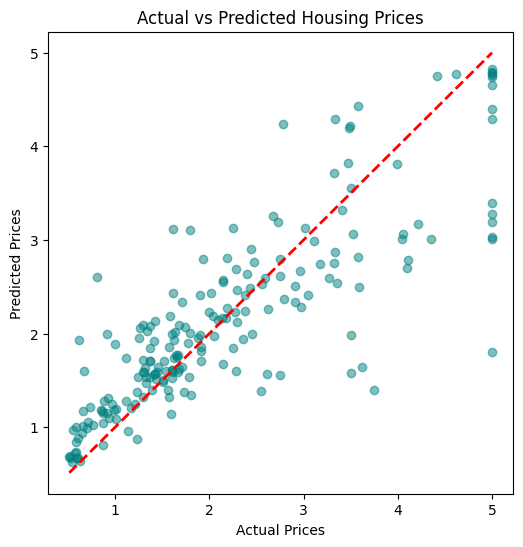

튜닝 전 R2: 0.6885, MSE: 0.4737
튜닝 후 R2: 0.6910, MSE: 0.4700
최적 파라미터: {'reg__max_depth': None, 'reg__n_estimators': 200}
K-Fold(5-Fold) 교차검증 평균 R2: 0.7100


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing(as_frame=True)
df = housing.frame.sample(n=1000, random_state=42)

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
mse = mean_squared_error(y_test, preds)

print(f"R2 Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Housing Prices')
plt.show()

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

kf = KFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RandomForestRegressor(random_state=42))
])

param_grid = {
    'reg__n_estimators': [50, 100, 200],
    'reg__max_depth': [5, 10, None]
}

grid = GridSearchCV(pipe, param_grid, cv=kf, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
tuned_preds = best_model.predict(X_test)

tuned_r2 = r2_score(y_test, tuned_preds)
tuned_mse = mean_squared_error(y_test, tuned_preds)

print(f"튜닝 전 R2: {r2:.4f}, MSE: {mse:.4f}")
print(f"튜닝 후 R2: {tuned_r2:.4f}, MSE: {tuned_mse:.4f}")
print(f"최적 파라미터: {grid.best_params_}")
print(f"K-Fold(5-Fold) 교차검증 평균 R2: {grid.best_score_:.4f}")
